# ANALIZA FILMOV IN NJIHOVEGA DNEVNEGA ZASLUŽKA NA PODLAGI LESTVICE BOX OFFICE MOJO

## UVOD
V projektni nalogi analiziram podatke o izbranih filmih in njihovem uspehu na lestvici največjega dnevnega zaslužka. Poleg dnevnega zaslužka za posamezne filme raziskujem tudi podatke o distributerju, trajanju in žanrih filmov, številu dni na lestvici ter datumu izida. Podatke sem zajela s spletne strani Box Office Mojo med 1. januarjem 2026 in 23. avgustom 2026, jih ustrezno predelala in shranila v obliki CSV datotek, ki so shranjene v mapi *podatki*. Nato sem podatke analizirala s pomočjo knjižnice pandas in jih predstavila z grafi ter diagrami. Namen analize je ugotoviti, kako se različne značilnosti filmov povezujejo z dnevnim zaslužkom in uspehom na prvem mestu. Poleg tega spremljam še spreminjanje povprečnega dnevnega zaslužka skozi čas ter podrobneje primerjam filma, ki sta bila največ dni na prvem mestu.

Pri interpretaciji rezultatov je treba upoštevati posebnost uporabljenega vira podatkov. Izbrana spletna stran se mi zdi primerna za zahtevnost projektne naloge, saj omogoča zajem podatkov iz spletnih strani, njihovo predelavo, urejanje in nadaljnjo analizo. Po drugi strani pa je smiselnost analize omejena, ker podatki predstavljajo zelo specifično kategorijo. To so zgolj film, ki so bili na določen dan med najuspešnejšimi glede na dnevni zaslužek. Zaradi tega nabora filmov ne morem neposredno enačiti s celotno populacijo filmov. Rezultati omogočajo primerjave znotraj tega nabora, ne omogočajo pa zanesljivih splošnih sklepov o vseh filmih, njihovih žanrih, distributerjih ali njihovi splošni uspešnosti.

V nadaljevanju odgovorim na naslednja raziskovalna vprašanja:
1. Ali obstaja povezava med največjim dnevnim zaslužkom filma in številom dni, ko je bil na 1. mestu?

2.1 Kateri žanri se najpogosteje pojavljajo med izbranimi filmi?

2.2 Kako pogosto se pojavljajo kombinacije žanrov pri izbranem naboru filmov in kateri pari žanrov se najpogosteje pojavljajo skupaj?

3. Ali se trajanje filma razlikuje glede na pet najpogostejših kombinacij žanrov?

4. Kateri distributerji prevladujejo med izbranimi filmi in ali se njihova zastopanost odraža tudi v povprečnem dnevnem zaslužku njihovih filmov?

5.1 Kako se povprečni dnevni zaslužek spreminja skozi čas?

5.2 Ali so skoki na grafu povezani z datumi izidov filmov?

6. Kako se razlikujeta dnevna zaslužka filmov, ki sta bila največ dni na prvem mestu?


## ANALIZA PODATKOV O FILMIH

V nadaljevanju preučujem različne podatke za izbrane filme, ki so se pojavljali na lestvici *Daily Box Office for 2026* med 1. januarjem 2026 in 23. avgustom 2026. V 235 dneh se je na lestvico uvrstilo 30 različnih filmov. Analiziram njihov dnevni in največji dnevni zaslužek, trajanje, distributerja, žanre ter število dni, ko so bili na prvem mestu ter datum izida.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

*Osnutek tabele za izbranih 30 filmov ter njihove kategorije.*

In [3]:
filmi = pd.read_csv('podatki/seznam_filmov_dopolnjeno.csv')
filmi.head()

,naslov,distributer,trajanje,žanri,datum izzida,št. dni na 1. mestu,največji dnevni zaslužek
0,Spider-Man: Brand New Day,Sony Pictures Releasing,2 hr 25 min,"akcijski, pustolovski, znanstvenofantastični","Jul 31, 2026",23,169843039
1,Insidious: Out of the Further,Sony Pictures Releasing,1 hr 46 min,"grozljivka, skrivnostni, triler","Aug 21, 2026",1,10675888
2,The Odyssey,Universal Pictures,2 hr 52 min,"akcijski, pustolovski, fantazijski","Jul 17, 2026",14,50977435
3,Moana,Walt Disney Studios Motion Pictures,1 hr 55 min,"akcijski, pustolovski, komedija, družinski, fa...","Jul 10, 2026",7,18510043
4,Minions & Monsters,Universal Pictures,1 hr 30 min,"pustolovski, animirani, komedija, družinski","Jul 1, 2026",9,16506115


*1. Ali obstaja povezava med največjim dnevnim zaslužkom filma in številom dni, ko je bil film na prvem mestu lestivice?*

Pri tem vprašanju preverjam, ali imajo filmi, ki so največ dni na lestvici, tudi najvišji dnevni zaslužek.

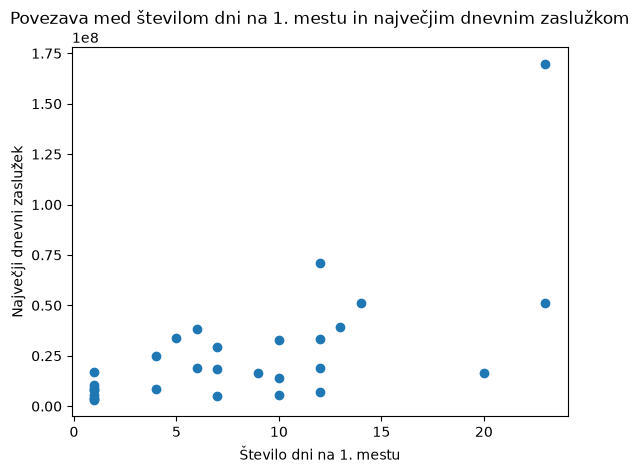

In [4]:
plt.scatter(filmi["št. dni na 1. mestu"], filmi["največji dnevni zaslužek"])

plt.xlabel("Število dni na 1. mestu")
plt.ylabel("Največji dnevni zaslužek")
plt.title("Povezava med številom dni na 1. mestu in največjim dnevnim zaslužkom")

plt.show()

Med številom dni na prvem mestu lestivice in največjim dnevnim zaslužkom je opazna pozitivna povezava. Vendar povezava ni popolna, saj se pri filmih z enakim ali podobnim številom dni na prvem mestu največji dnevni zaslužek lahko precej razlikuje. Ocenim lahko, da za večino filmov večji zaslužek pomeni višje število dni na prvem mestu. Filmi, ki so se na prvo mesto uvrstili samo za en dan, imajo praviloma nižji največji dnevni zaslužek kot filmi, ki so bili na lestvici več kot en dan. 
Na grafu posebej izstopata filma na skrajno desni strani, ki sta bila največ dni na prvem mestu, vendar se njuna največja dnevna zaslužka precej razlikujeta. Sklepam lahko torej, da število dni na prvem mestu ne določa višine največjega dnevnega zaslužka. Na uspešnost filma vplivajo tudi drugi dejanviki, nekatere od teh raziskujem v nadaljevanju naloge.

*2.1 Kateri žanri se najpogosteje pojavljajo med izbranimi filmi?*

Preverjam, kateri žanri se najpogosteje pojavljajo med izbranimi filmi. Za prikaz pogostosti posameznih žanrov uporablim tabelo in stolpični diagram, saj omogoča pregledno primerjavo števila pojavitev med različnimi žanrskimi kategorijami.

In [24]:
zanri = filmi["žanri"].str.split(",").explode().str.strip()

tabela_zanrov = (zanri.value_counts().reset_index())

tabela_zanrov.columns = ["Žanr", "Število filmov"]

tabela_zanrov

,Žanr,Število filmov
0,pustolovski,15
1,znanstvenofantastični,12
2,komedija,12
3,drama,10
4,akcijski,9
5,grozljivka,9
6,triler,9
7,družinski,8
8,fantazijski,7
9,animirani,7


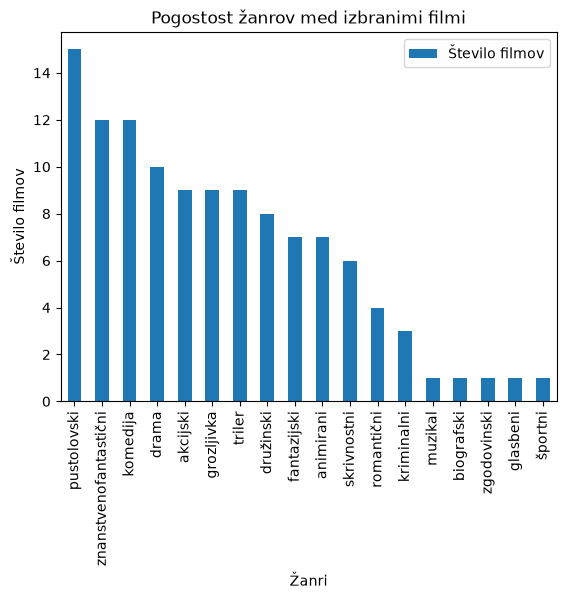

In [25]:
tabela_zanrov.plot(x="Žanr", y="Število filmov", kind="bar")
plt.xlabel("Žanri")
plt.ylabel("Število filmov")
plt.title("Pogostost žanrov med izbranimi filmi")
plt.show()

Med izbranimi filmi je najpogosteje zastopan pustolovski žanr, ki se pojavi pri 15 filmih. Sledita znanstvenofantastični žanr in komedija z 12 pojavitvami, nato drama z desetimi. Med pogostejšimi so tudi akcijski, pustolovski in znanstvenofantastični žanri. Manj priljubljeni so muzikal, biografski, zgodovinski, glasbeni in športni žanri, saj se pojavijo le enkrat. To kaže na neenakomerno zastopanost žanrov v izbranem vzorcu. Vrste žanrov se lahko pri posameznem filmu med seboj prepletajo, saj imajo nekateri filmi več navedenih žanrov, zato se ponuja naslednje vprašanje.

*2.2 Kako pogosto se pojavljajo kombinacije žanrov pri izbranem naboru filmov in kateri pari žanrov se najpogosteje pojavljajo skupaj?*

Najprej preverim , koliko različnih žanrov imajo posamezni filmi, nato pa primerjam pare žanrov, da ugotovim, kateri so najpogostejši.

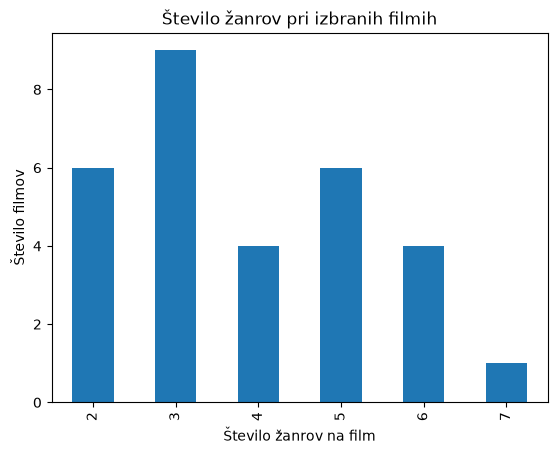

In [26]:
stevilo_zanrov_na_film = filmi["žanri"].str.split(",").str.len()
stevilo_zanrov_na_film.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Število žanrov na film")
plt.ylabel("Število filmov")
plt.title("Število žanrov pri izbranih filmih")

plt.show()

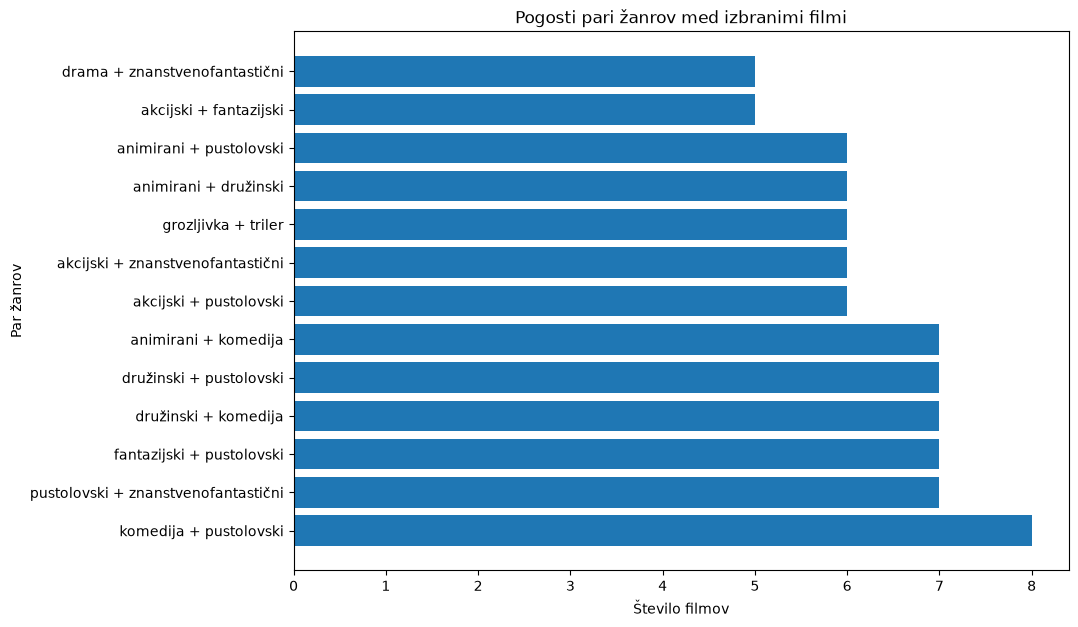

In [7]:
from itertools import combinations
from collections import Counter

pari_zanrov = []

for zanri_filma in filmi["žanri"]:
    seznam_zanrov = [z.strip() for z in zanri_filma.split(",")]
    pari = list(combinations(sorted(seznam_zanrov), 2))
    pari_zanrov.extend(pari)

stevilo_parov = Counter(pari_zanrov)

pogosti_pari = [(par, stevilo) for par, stevilo in stevilo_parov.items() if stevilo >= 5]

pogosti_pari = sorted(pogosti_pari, key=lambda x: x[1], reverse=True)

oznake = [f"{a} + {b}" for (a, b), stevilo in pogosti_pari]
vrednosti = [stevilo for (a, b), stevilo in pogosti_pari]

plt.figure(figsize=(10, 7))
plt.barh(oznake, vrednosti)
plt.xlabel("Število filmov")
plt.ylabel("Par žanrov")
plt.title("Pogosti pari žanrov med izbranimi filmi")

plt.show()

Izbrani filmi niso omejeni na en sam žanr, temveč imajo več kombinacij. Največ filmov, devet, ima po tri žanre, šest filmov pa ima dva oz. pet žanrov. Štirje filmi imajo štiri žanre, štirje šest žanrov, en film pa ima kar sedem različnih žanrskih oznak. Analiza pokaže, da se najpogosteje skupaj pojavljata komedija in pustolovski žanr, ki se pojavita pri devetih filmih. Sledita kombinaciji družinskega ter pustolovskega žanra z osmimi pojavitvami. Več parov ima po sedem pojavitev, med drugim pustolovski in znanstvenofantastični, fantazijski in pustolovski ter družinski in komedija. Pri tem izstopa predvsem pustolovski žanr, kar potrjuje že vprašanje 2.1, saj je zelo pogosto prisoten v različnih komcinacijah žanrov, kot so komedija, družinski, znanstvenofantastični, fantazijski ali akcijski žanr. 


*3. Ali se trajanje filma razlikuje glede na pet najpogostejših kombinacij žanrov?*

Na podlagi rezultatov analize kombinacij žanrov iz prejšnjega vprašanja primerjam povprečno trajanje filmov glede na pet najpogostejših parov žanrov. Zanimajo me, ali so določene kombinacije povezane z daljšim ali krajšim trajanjem filmov.


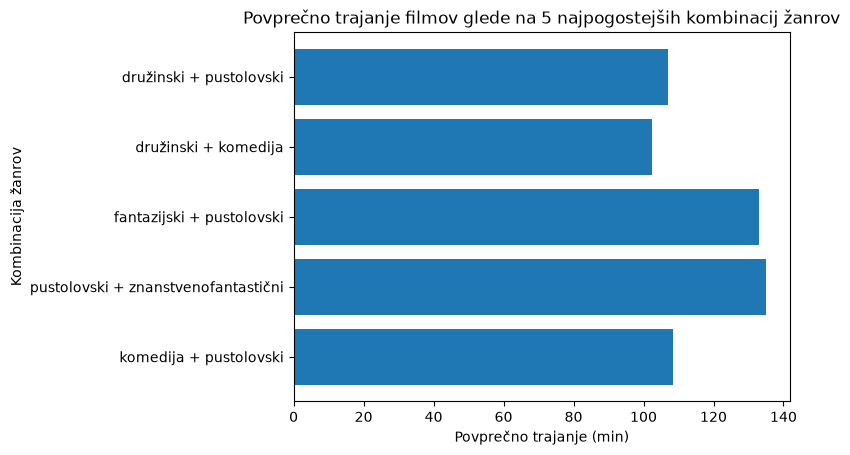


 VREDNOSTI TRAJANJA:
komedija + pustolovski = 108.50 minut
pustolovski + znanstvenofantastični = 135.00 minut
fantazijski + pustolovski = 133.14 minut
družinski + komedija = 102.43 minut
družinski + pustolovski = 107.00 minut


In [16]:
trajanje_v_min = []

for cas in filmi["trajanje"]:
    deli = cas.split()
    ure = int(deli[0])
    minute = int(deli[2])
    trajanje_v_min.append(ure * 60 + minute)

filmi["trajanje_min"] = trajanje_v_min


povprecno_trajanje_parov = []

for (a, b), stevilo in pogosti_pari[:5]:
    trajanja = []

    for i, zanri in enumerate(filmi["žanri"]):
        if a in zanri and b in zanri:
            trajanja.append(filmi["trajanje_min"].iloc[i])

    povprecje = sum(trajanja) / len(trajanja)
    povprecno_trajanje_parov.append(povprecje)


oznake = [f"{a} + {b}" for (a, b), stevilo in pogosti_pari[:5]]

plt.barh(oznake, povprecno_trajanje_parov)

plt.xlabel("Povprečno trajanje (min)")
plt.ylabel("Kombinacija žanrov")
plt.title("Povprečno trajanje filmov glede na 5 najpogostejših kombinacij žanrov")

plt.show()

print("\n VREDNOSTI TRAJANJA:")

for oznaka, povprecje in zip(
    oznake,
    povprecno_trajanje_parov
):
    print(f"{oznaka} = {povprecje:.2f} minut")

Rezultati kažejo, da se povprečno trajanje med posameznimi kombinacijami razlikuje. Izstopata kombinaciji fantazijski + pustolovski in pustolovski + znanstvenofantastični žanr, pri katerih je povprečno trajanje približno 25-35 min daljše kot pri ostalih priljubljenih kombinacijah filmov. Pri interpretaciji rezultatov je treba upoštevati, da ima posamezen film lahko več žanrov, zato se lahko isti film pojavi pri več analiziranih kombinacijah. Npr. film ima lahko več različnih kombinacij žanrov, ki se pojavijo med petimi najpogostejšimi, zato njegovo trajanje prispeva k povprečju vseh teh kombinacij. Skupine torej niso popolnoma ločene in vsak film ne pripada samo eni kombinaciji. Na podlagi grafa lahko zaključim, da so med izbranimi petimi kombinacijami najdaljši filmi povezani predvsem s kombinacijama fantazijskega in pustolovskega žanra ter pustolovskega in znanstvenofantastičnega žanra.

*4. Kateri distributerji prevladujejo med izbranimi filmi in ali se njihova zastopanost odraža tudi v povprečnem dnevnem zaslužku filmov?*

Preverjam, ali imajo distributerji, ki se med izbranimi filmi pojavljajo pogosteje, tudi višji povprečni dnevni zaslužek.

In [29]:
stevilo_distributerjev = filmi["distributer"].value_counts()
tabela_distributerjev = stevilo_distributerjev.reset_index()
tabela_distributerjev.columns = ["Distributer", "Število filmov"]
tabela_distributerjev

,Distributer,Število filmov
0,Walt Disney Studios Motion Pictures,7
1,Universal Pictures,5
2,Sony Pictures Releasing,4
3,Paramount Pictures,2
4,Warner Bros.,2
5,Amazon MGM Studios,2
6,Focus Features,1
7,Fathom Entertainment,1
8,A24,1
9,Lionsgate,1


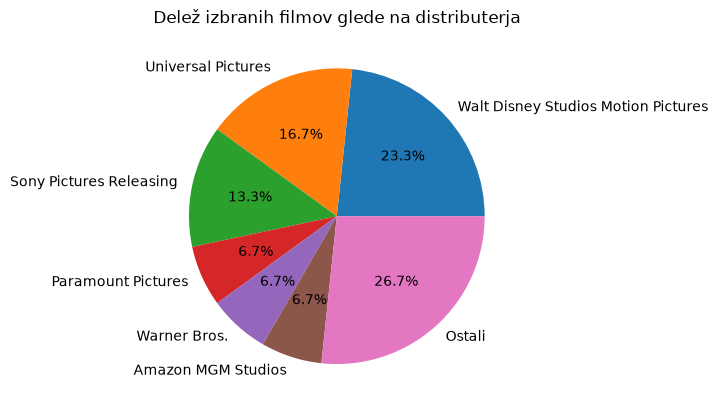

In [30]:
stevilo_distributerjev = filmi["distributer"].value_counts()

glavni = stevilo_distributerjev[stevilo_distributerjev >= 2]

ostali = stevilo_distributerjev[stevilo_distributerjev == 1].sum()

podatki_graf = pd.concat([glavni, pd.Series({"Ostali": ostali})])

podatki_graf.plot(kind="pie", autopct="%1.1f%%")

plt.title("Delež izbranih filmov glede na distributerja")

plt.show()

In [31]:
dnevni_podatki = pd.read_csv("podatki/dnevni_podatki.csv")
povprecni_zasluzek = dnevni_podatki.groupby("naslov")["dnevni zaslužek"].mean()
filmi["povprecni_dnevni_zasluzek"] = filmi["naslov"].map(povprecni_zasluzek)

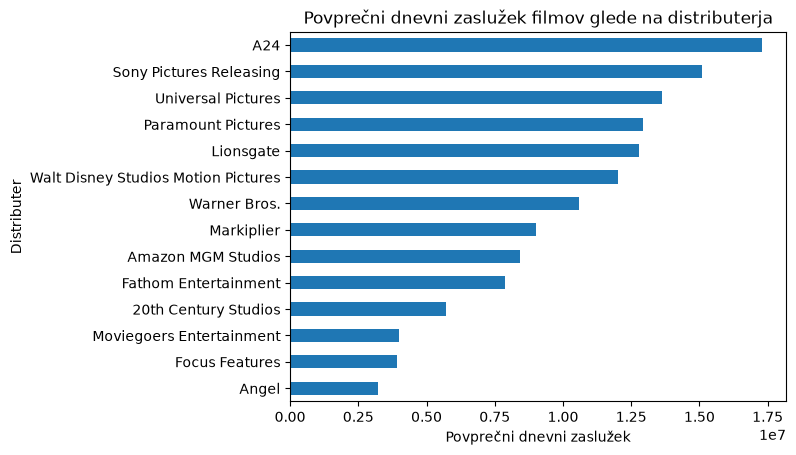

In [32]:
povprecje_distributerjev = filmi.groupby("distributer")["povprecni_dnevni_zasluzek"].mean()
povprecje_distributerjev = povprecje_distributerjev.sort_values()

povprecje_distributerjev.plot(kind="barh")

plt.xlabel("Povprečni dnevni zaslužek")
plt.ylabel("Distributer")
plt.title("Povprečni dnevni zaslužek filmov glede na distributerja")

plt.show()

Najbolj zastopani distributerji so Walt Disney Studios Motion Pictures, ki ima sedem filmov, sledita Universal Pictures s petimi filmi in Sony Pictures Releasing s štirimi filmi. Omenjeni distributerji si delijo več kot polovico najuspešnejših filmov glede na zastopanost na 1. mestu lestvice. Ostali distributerji imajo slabšo zastopanost z enim al dvema filmoma.
Zdi se, da bi bili ti trije distributerji tudi najuspešnjši glede na največji povprečni dnevni zaslužek, vendar nadaljna analiza temu močno nasprotuje. Najvišji povprečni dnevni zaslužek ima A24, čeprav ima med izbranimi filmi samo enega. Sledijo Sony Pictures Releasing, Universal Pictures in Paramount Pictures. Walt Disney Studios Motion Pictures, ki je najbolj zastopan distributer, se po povprečnem dnevnem zaslužku uvršča šele na šesto mesto.
Rezultati kažejo, da večja zastopanost distributerja med izbranimi filmi ne pomeni nujno tudi višjega povprečnega dnevnega zaslužka njegovih filmov. Vendar na podlagi teh podatkov ne morem določiti, kateri distributer je na splošno najuspešnejši. Analiza temelji le na izbranih filmih in dnevnih podatkih, ki jih imamo za dneve, ko so bili filmi vključeni v obravnavano lestvico. Tako lahko zaključim le, kateri distributerji so bili v vzorcu najbolj zastopani in kateri so imeli v tem vzorcu najvišji povprečni dnevni zaslužek. Celotna slika bi se lahko precej spremenila, če bi računala s podatki, ko filmi niso bili uvrščni na lestvico, kljub temu pa so ustvarjali dnevni zaslužek.

*5.1 Kako se povprečni dnevni zaslužek izbranih filmov spreminja skozi čas?*

*5.2 Ali so skoki na grafu povezani z datumi izidov filmov?*

S časovnim prikazom želim prepoznati obdobja večjih in manjših zaslužkov ter izrazitejše skoke na grafu. Nato preverim, ali so ti skoki povezani z datumi izidov filmov.

In [33]:
filmi = pd.read_csv("podatki/seznam_filmov_dopolnjeno.csv")
filmi["datum izzida"] = pd.to_datetime(filmi["datum izzida"])

datumi_izidov = filmi[["naslov", "datum izzida"]]
print(datumi_izidov.shape)

(30, 2)


*OPOMBA: Zgornja tabela je velikosti 30 × 2, vendar bom za označevanje na spodnjem grafu uporabila le 28 filmov, saj obravnavam podatke za leto 2026. Dva filma iz našega nabora sta bila namreč izdana že leta 2025.*

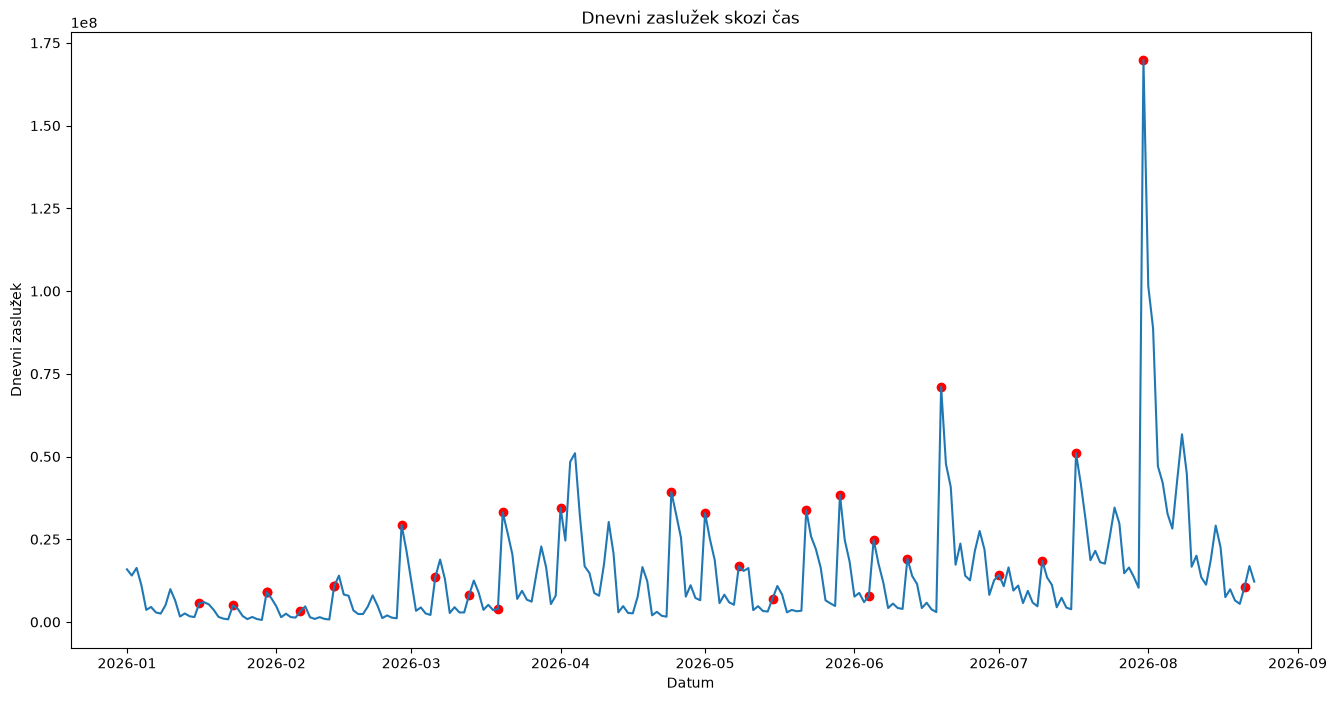

In [34]:
dnevni_podatki = pd.read_csv("podatki/dnevni_podatki.csv")

dnevni_podatki["datum"] = pd.to_datetime(dnevni_podatki["datum"] + " 2026")

datumi_izidov = datumi_izidov[datumi_izidov["datum izzida"].dt.year == 2026]

vrednosti_na_dan_izida = dnevni_podatki.set_index(
    "datum"
).loc[
    datumi_izidov["datum izzida"],
    "dnevni zaslužek"
]

plt.figure(figsize=(16, 8))

plt.plot(dnevni_podatki["datum"], dnevni_podatki["dnevni zaslužek"])

plt.scatter(
    datumi_izidov["datum izzida"],
    vrednosti_na_dan_izida,
    color="red"
)

plt.xlabel("Datum")
plt.ylabel("Dnevni zaslužek")
plt.title("Dnevni zaslužek skozi čas")

plt.show()

Povprečni dnevni zaslužek se skozi leto spreminja in niha. Največji porasti so skoncentrirani predvsem v obdobjih večjih filmskih izidov, medtem ko so med posameznimi izidi vidna tudi obdobja nižjega zaslužka.
Sklepam, da so izidi filmov povezani s povečanjem povprečnega dnevnega zaslužka, vendar povezava ni vedno prisotna. Na zaslužek tako vplivajo tudi drugi dejavniki, ki jih v projektni nalogi ne obravnavam. Najizrazitejši skok v povprečnem dnevnem zaslužku se pojavi 31. julija 2026, ko je izšel film Spider-Man: Brand New Day. To je tudi najvišji zabeleženi skok v obravnavanem obdobju in predstavlja najbolj očiten primer povezave med filmskim izidom in povečanjem zaslužka.

*6. Kako se razlikujeta dnevna zaslužka filmov, ki sta bila največ dni na prvem mestu?*

Primerjam filma, ki sta bila med izbranimi največ dni na prvem mestu lestvice. Ker sta bila Spider-Man: Brand New Day in The Super Mario Galaxy Movie na prvem mestu enako dolgo, ju primerjam v 23-dnevnem obdobju. Pri tem spremljam njun dnevni zaslužek in primerjam skupni ter povprečni zaslužek v tem obdobju.

In [35]:
filmi = pd.read_csv("podatki/seznam_filmov_dopolnjeno.csv")

najvec_dni = filmi["št. dni na 1. mestu"].max()

filmi_najvec_dni = filmi[filmi["št. dni na 1. mestu"] == najvec_dni]

print(filmi_najvec_dni[["naslov", "št. dni na 1. mestu"]])

                          naslov  št. dni na 1. mestu
0      Spider-Man: Brand New Day                   23
15  The Super Mario Galaxy Movie                   23


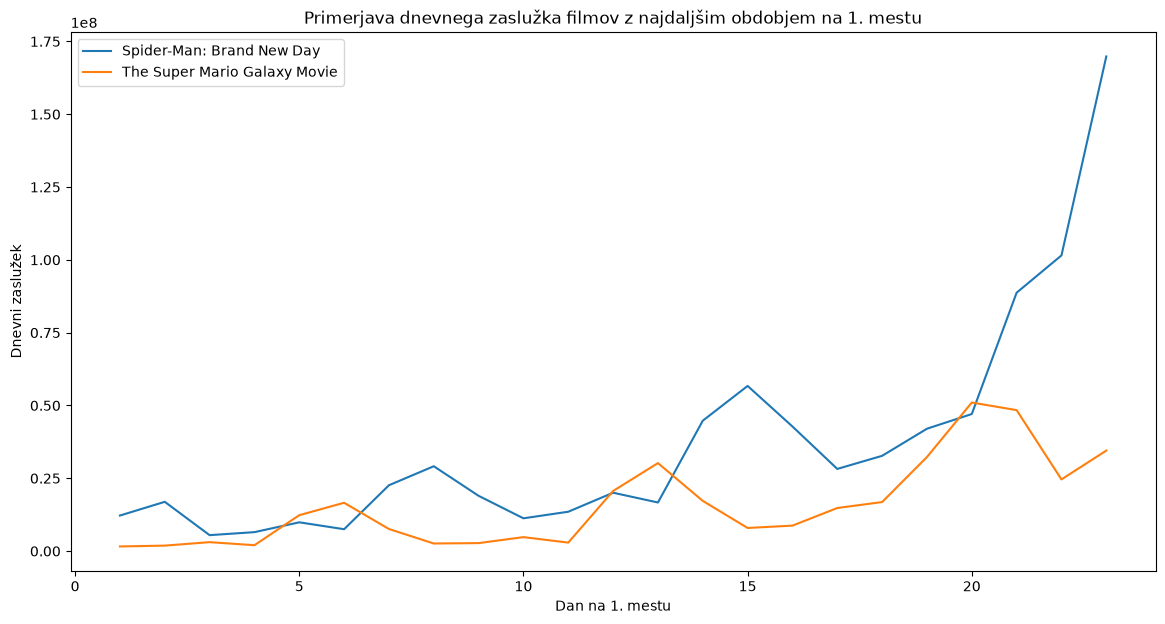

In [36]:
dnevni_podatki = pd.read_csv("podatki/dnevni_podatki.csv")

film_1 = dnevni_podatki[dnevni_podatki["naslov"] == 'Spider-Man: Brand New Day'].copy()
film_2 = dnevni_podatki[dnevni_podatki["naslov"] == 'The Super Mario Galaxy Movie'].copy()

film_1['dan'] = range(1, len(film_1) + 1)
film_2['dan'] = range(1, len(film_2) + 1)

plt.figure(figsize=(14, 7))
plt.plot(film_1['dan'], film_1['dnevni zaslužek'], label = 'Spider-Man: Brand New Day')
plt.plot(film_2['dan'], film_2['dnevni zaslužek'], label = 'The Super Mario Galaxy Movie')


plt.xlabel('Dan na 1. mestu')
plt.ylabel('Dnevni zaslužek')
plt.title('Primerjava dnevnega zaslužka filmov z najdaljšim obdobjem na 1. mestu')
plt.legend()
plt.show()


In [37]:
skupni_1 = film_1['dnevni zaslužek'].sum()
skupni_2 = film_2['dnevni zaslužek'].sum()

povprecni_1 = film_1['dnevni zaslužek'].mean()
povprecni_2 = film_2['dnevni zaslužek'].mean()

razlika_skupni = skupni_1 - skupni_2
razlika_povprecni = povprecni_1 - povprecni_2

print("Razlika v skupnem zaslužku:", razlika_skupni)

odstotna_povprecni = (razlika_povprecni / povprecni_2) * 100
print("Odstotna razlika v povprečnem zaslužku:", odstotna_povprecni, "%")

tabela_zasluzek = pd.DataFrame({
    "Film": ["Spider-Man: Brand New Day", "The Super Mario Galaxy Movie"],
    "Skupni zaslužek": [skupni_1, skupni_2],
    "Povprečni dnevni zaslužek": [povprecni_1, povprecni_2]
})

tabela_zasluzek["Povprečni dnevni zaslužek"] = tabela_zasluzek["Povprečni dnevni zaslužek"].round(0).astype(int)
tabela_zasluzek


Razlika v skupnem zaslužku: 479727524
Odstotna razlika v povprečnem zaslužku: 131.3267232084697 %


,Film,Skupni zaslužek,Povprečni dnevni zaslužek
0,Spider-Man: Brand New Day,845020674,36740029
1,The Super Mario Galaxy Movie,365293150,15882311


Primerjava kaže, da je bil Spider-Man: Brand New Day v obdobju 23 dni, ko sta bila oba filma na 1. mestu, glede na dnevni zaslužek uspešnejši od The Super Mario Galaxy Movie. Spider-Man je v tem obdobju dosegel 845.020.674$ skupnega zaslužka, medtem ko je The Super Mario Galaxy Movie dosegel 365.293.150$, kar predstavlja razliko 479.727.524$. Tudi povprečni dnevni zaslužek je bil pri Spider-Manu višji za približno 131,33 %. Pri obeh filmih je mogoče opaziti spreminjanje zaslužka skozi zaporedne dni. Zanimivo je opaziti, da se krivulji obeh filmov vzpenjata čez čas, kar kaže na rast dnevnega zaslužka v opazovanem obdobju. Na podlagi primerjave sklepam, da samo število dni na 1. mestu ne zagotavlja višjega dnevnega zaslužka. 
Opozoriti moram, da primerjava temelji le na dnevih, ko sta bila filma med najuspešnejšimi oz. na 1. mestu, zato rezultat ne predstavlja njunega celotnega zaslužka skozi celotno predvajanje.

## Zaključek

V projektni nalogi analiziram izbrane podatke o filmih in njihovem dnevnem zaslužku. S pomočjo izračunov, tabel in grafičnih prikazov preverjam šest glavnih raziskovalnih vprašanj.

Ugotovila sem, da je med številom dni na prvem mestu in največjim dnevnim zaslužkom opazna pozitivna povezava. Filmi, ki so bili na prvem mestu več dni, imajo praviloma višji največji dnevni zaslužek, vendar povezava ni popolna.
Opazila sem, da je najpogosteje zastopan pustolovski žanr. Ker imajo filmi lahko več žanrov in se žanri med seboj prepletajo, sem raziskovala tudi najpogostejše pare žanrov. Najpogosteje se skupaj pojavljata komedija in pustolovski žanr ter pustolovski žanr v kombinaciji z družinskim, znanstvenofantastičnim in fantazijskim. Glede na pet najpogostejših kombinacij sem raziskovala tudi trajanje. Najdaljše povprečno trajanje dosega par fantazijski in pustolovski žanr ter pustolovski in znanstvenofantastični. Pri tem upoštevam, da posamezen film lahko pripada več kombinacijam, zato skupine niso popolnoma ločene in rezultatov ne morem razlagati tako, da vsak film pripada samo eni žanrski skupini.
Najbolj zastopani distributerji so Walt Disney Studios Motion Pictures, Universal Pictures in Sony Pictures Releasing. Vendar večja zastopanost distributerja ne pomeni tudi višjega povprečnega dnevnega zaslužka. Očiten protiprimer je povprečni dnevni zaslužek, ki ga ima A24, čeprav je v izbranem naboru zastopan samo z enim filmom.
Pri spremljanju dnevnega zaslužka skozi čas ugotavljam, da zaslužek niha. Večji porasti so v veliki meri povezani z dnevi izidov filmov. Najizrazitejši skok se pojavi 31. julija 2026, ko izide film Spider-Man: Brand New Day. Vendar povezave med izidom filma in povečanjem zaslužka ne morem potrditi pri vsakem posameznem skoku, saj na dnevni zaslužek vplivajo tudi drugi dejavniki, ki jih v tej nalogi ne obravnavam.
Razmislila sem, ali sta filma Spider-Man: Brand New Day in The Super Mario Galaxy Movie primerljiva glede na zaslužek, saj sta bila oba 23 dni uvrščena na lestvici. Spider-Man: Brand New Day v tem obdobju doseže višji skupni in povprečni dnevni zaslužek, njegov povprečni dnevni zaslužek je namreč višji za 131,33 %.

Pri vrednotenju celotnih rezultatov moram upoštevati predvsem omejitev uporabljenih podatkov. Spletna stran, ki sem jo izbrala kot vir, je za projektno nalogo primerna z vidika zahtevnosti, saj omogoča dovolj obsežen zajem, predelavo in analizo podatkov. Hkrati pa podatki niso idealni za oblikovanje splošnih sklepov o uspešnosti filmov, saj obravnavam le filme, ki se pojavljajo na dnevni lestvici najuspešnejših filmov glede na zaslužek. Lestvica sama po sebi zajema zelo specifično kategorijo. Zaradi tega moj nabor ne predstavlja naključnega vzorca vseh filmov. Rezultatov ne morem posplošiti na vse filme. Prav tako ne morem določiti, kateri žanr, distributer ali značilnost filma je na splošno najbolj uspešna. Rezultati opisujejo zgolj odnose in značilnosti znotraj izbranega nabora filmov. Kljub tej omejitvi mi analiza omogoča primerjavo filmov ter njihovih značilnosti in prepoznavanje določenih vzorcev glede na dnevni zaslužek, žanre, distributerje in trajanje. Iz celotne analize podatkov sklepam, da uspešnosti filma ni mogoče zanesljivo oceniti na podlagi samo enega vidika. Posamezne značilnosti lahko pokažejo določene razlike med filmi, vendar nobena od analiziranih spremenljivk sama po sebi ne pojasni njihove celotne uspešnosti. Za natančnejšo oceno bi bilo zato smiselno vključiti več različnih dejavnikov in širši nabor filmov.
